# PDoS

Projected electronic density of state versus energy


In [1]:
# Graphene-BC₃ (Hollow)

from vmatplot.PDoS import extract_pdos, extract_segment_pdos
from vmatplot.PDoS_plotting import *

PBE_total = extract_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25")
PBE_B     = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 1, 2)
PBE_C_top = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 3, 8)
PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 9, 16)

HSE_total = extract_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow")
HSE_B     = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 1, 2)
HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 3, 8)
HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 9, 16)

title_total = "Total PDoS"
title_C_top = "PDoS for Carbon in Graphene"
title_B_BC3 = "PDoS for Boron in BC₃"
title_C_BC3 = "PDoS for Carbon in BC₃"

matters_dir = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    [title_C_top, 6, 10,    "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_B_BC3, 6, 3,     "HSE06", HSE_B,     "PBE", PBE_B],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dash"]
]


In [1]:
from vmatplot.PDoS import extract_pdos

PBE_total = extract_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25")
HSE_total = extract_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow")

title_total = "Total PDoS"

test_dir = [
    [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]


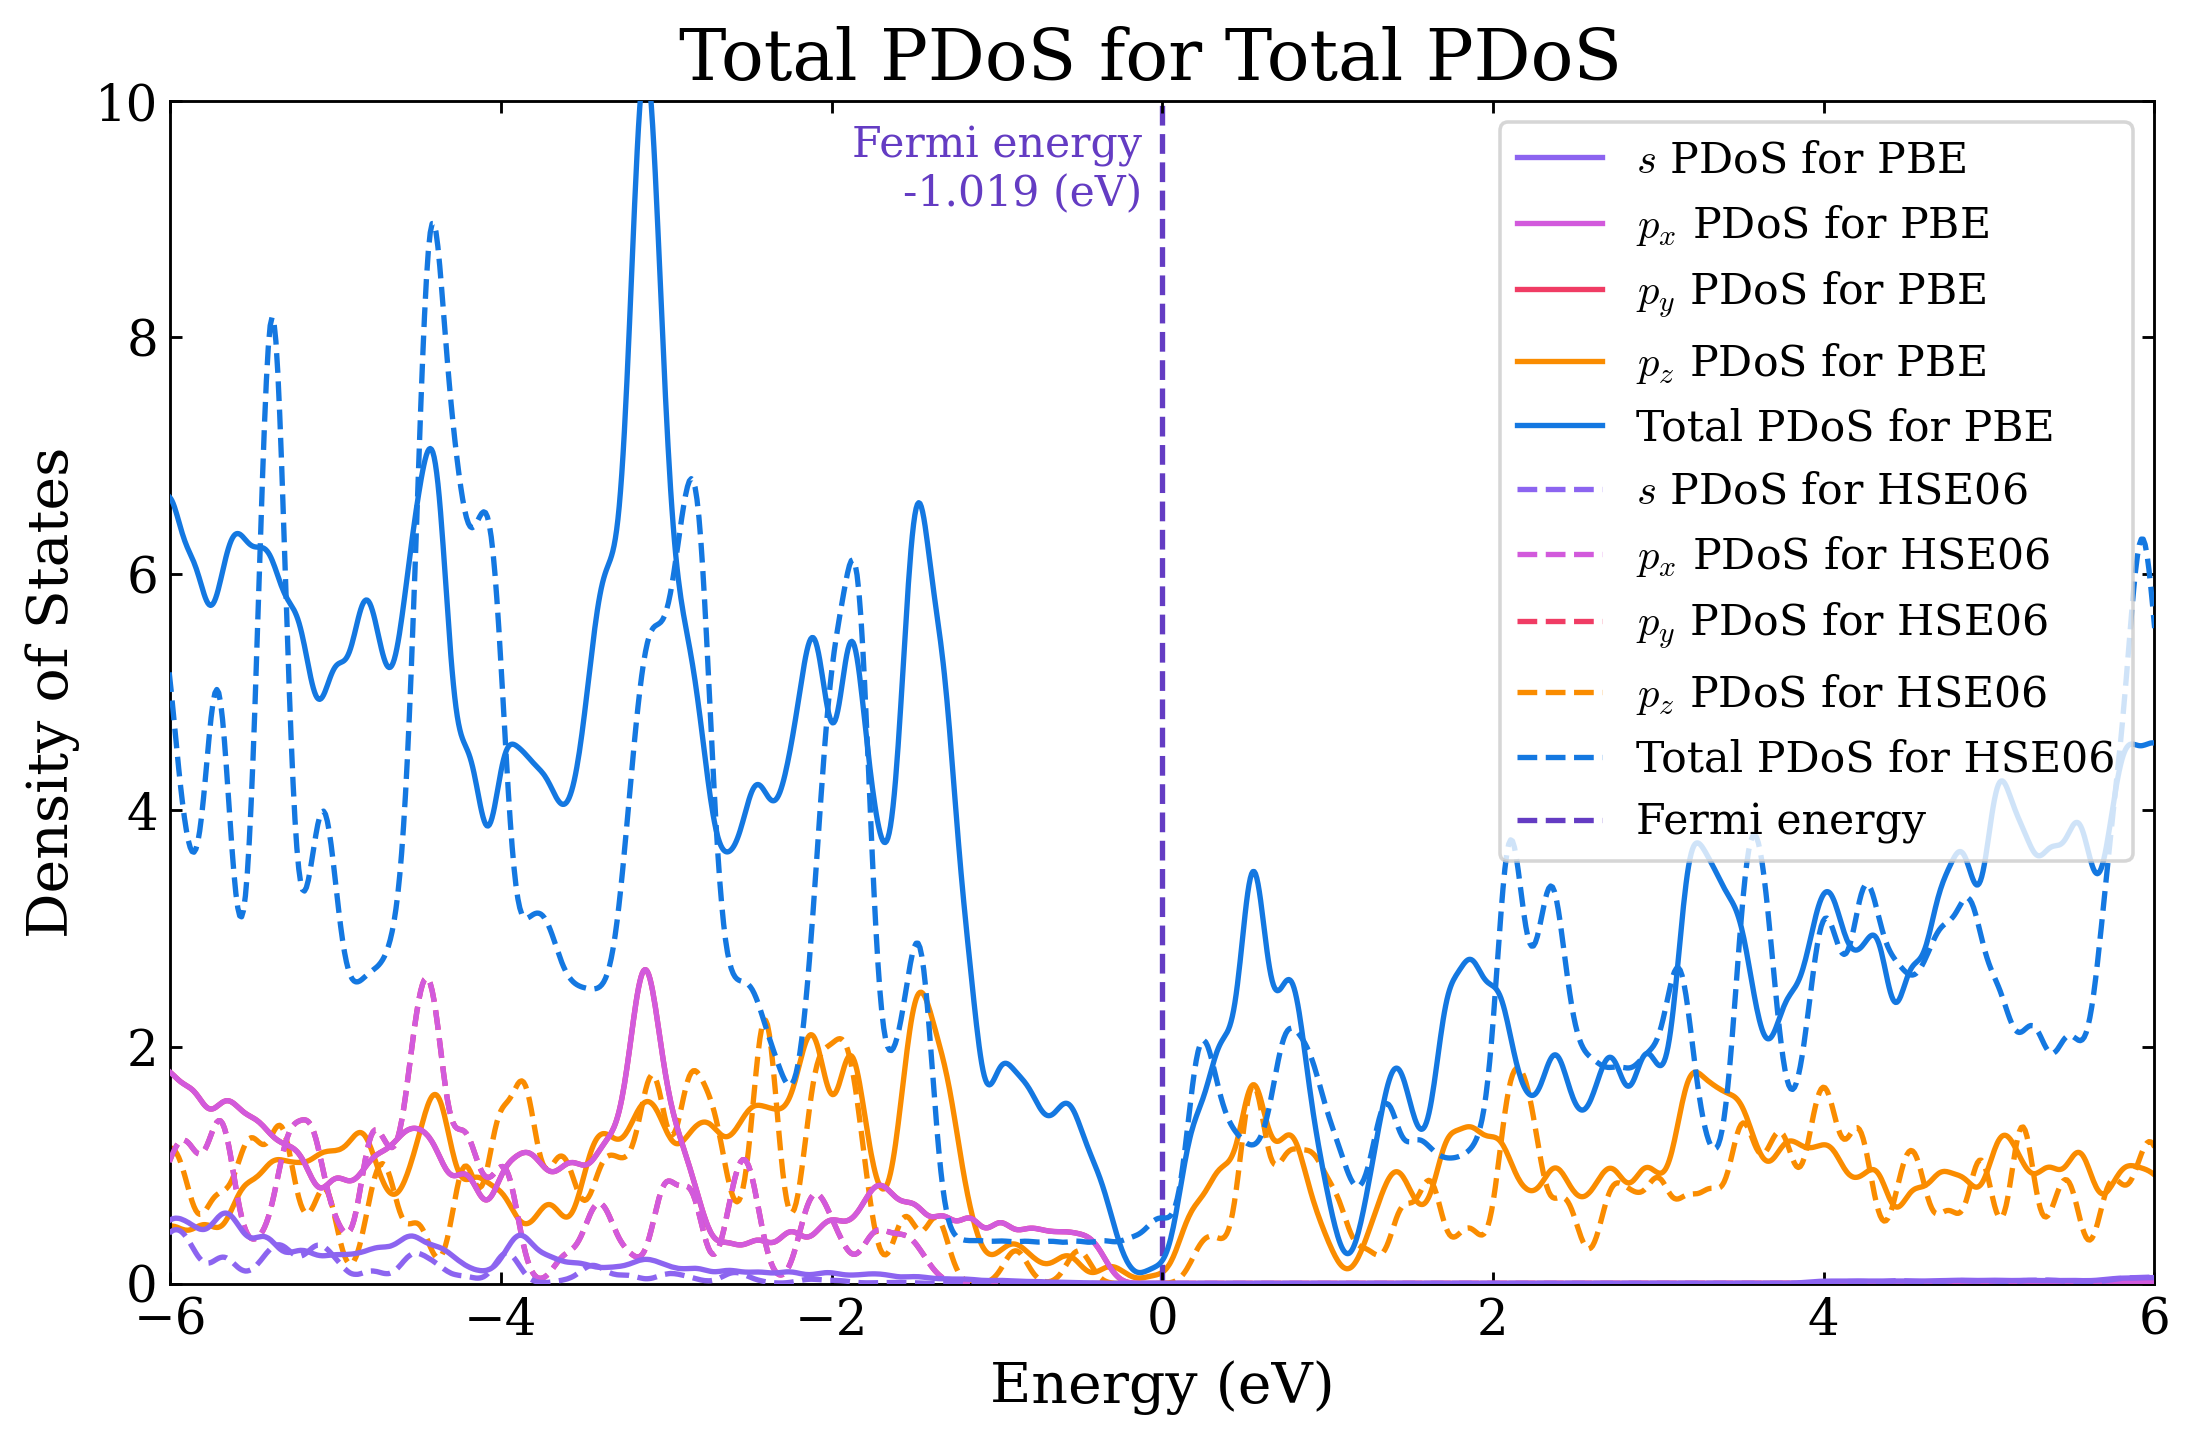

In [3]:
import matplotlib.pyplot as plt
from vmatplot.output import canvas_setting, color_sampling

def pdos_segment_total(matters_list = None):
    # Help information
    help_info = "help information"
    if matters_list in ["help", "Help"]:
        print(help_info)
    # Figure Settings
    fig_setting = canvas_setting()
    plt.figure(figsize=fig_setting[0], dpi = fig_setting[1])
    params = fig_setting[2]; plt.rcParams.update(params)
    plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

    # Color calling
    fermi_color = color_sampling("Violet")

    # Ranges
    x_range = matters_list[0][1]
    y_top = matters_list[0][2]

    # Matter
    matter = matters_list

    plt.plot(matter[0][4][8], matter[0][4][9],  c=color_sampling(matter[1][0])[3], alpha = matter[1][1], linestyle=matter[1][2], label=f"$s$ PDoS for {matter[0][3]}",  zorder=4)
    plt.plot(matter[0][4][8], matter[0][4][12], c=color_sampling(matter[1][0])[4], alpha = matter[1][1], linestyle=matter[1][2], label=f"$p_x$ PDoS for {matter[0][3]}",zorder=3)
    plt.plot(matter[0][4][8], matter[0][4][10], c=color_sampling(matter[1][0])[5], alpha = matter[1][1], linestyle=matter[1][2], label=f"$p_y$ PDoS for {matter[0][3]}",zorder=2)
    plt.plot(matter[0][4][8], matter[0][4][11], c=color_sampling(matter[1][0])[6], alpha = matter[1][1], linestyle=matter[1][2], label=f"$p_z$ PDoS for {matter[0][3]}",zorder=1)

    plt.plot(matter[0][4][8], matter[0][4][6], c=color_sampling(matter[1][0])[1], label=f"Total PDoS for {matter[0][3]}", alpha=matter[1][1], linestyle=matter[1][2], zorder = 5)
    efermi = matter[0][4][0]

    if len(matters_list[0]) == 7:
        plt.plot(matter[0][4+2][8], matter[0][4+2][9],  c=color_sampling(matter[1][0+3])[3], alpha = matter[1][1+3], linestyle=matter[1][2+3], label=f"$s$ PDoS for {matter[0][3+2]}",  zorder=4)
        plt.plot(matter[0][4+2][8], matter[0][4+2][12], c=color_sampling(matter[1][0+3])[4], alpha = matter[1][1+3], linestyle=matter[1][2+3], label=f"$p_x$ PDoS for {matter[0][3+2]}",zorder=3)
        plt.plot(matter[0][4+2][8], matter[0][4+2][10], c=color_sampling(matter[1][0+3])[5], alpha = matter[1][1+3], linestyle=matter[1][2+3], label=f"$p_y$ PDoS for {matter[0][3+2]}",zorder=2)
        plt.plot(matter[0][4+2][8], matter[0][4+2][11], c=color_sampling(matter[1][0+3])[6], alpha = matter[1][1+3], linestyle=matter[1][2+3], label=f"$p_z$ PDoS for {matter[0][3+2]}",zorder=1)

        plt.plot(matter[0][4+2][8], matter[0][4+2][6], c=color_sampling(matter[1][0+3])[1], label=f"Total PDoS for {matter[0][3+2]}", alpha=matter[1][1+3], linestyle=matter[1][2+3], zorder = 5)

    # Plot Fermi energy as a vertical line
    shift = efermi
    plt.axvline(x = efermi-shift, linestyle="--", c=fermi_color[0], alpha=1.00, label="Fermi energy", zorder = 1)
    fermi_energy_text = f"Fermi energy\n{efermi:.3f} (eV)"
    plt.text(efermi-shift-x_range*0.02, y_top*0.98, fermi_energy_text, fontsize =1.0*12, c=fermi_color[0], rotation=0, va = "top", ha="right")

    # Title
    # plt.title(f"Electronic density of state for {title} ({supplement})")
    plt.title(f"Total PDoS for {matter[0][0]} ")
    plt.ylabel(r"Density of States"); plt.xlabel(r"Energy (eV)")

    plt.ylim(0, y_top)
    plt.xlim(x_range*(-1), x_range)
    # plt.legend(loc="best")
    plt.legend(loc="upper right")


helo_info = "help information"

def plot_pdos_segment(matters):
    if len(matters) == 1:
        print(helo_info)
    if len(matters) == 2:
        return pdos_segment_total(matters)

## Testing areas
len(test_dir)

plot_pdos_segment(test_dir)

# test_dir[0][4][8]


In [ ]:
# # Graphene-Borophene (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 1, 8)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 9, 16)

# HSE_total = extract_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 1, 8)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 9, 16)

# title_total = "Total PDoS"
# title_C_top = "PDoS for Carbon in Graphene"
# title_B     = "PDoS for Boron in Borophene"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 4.5,   "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B,     6, 4.5,   "PBE", PBE_B,       "HSE06", HSE_B]
# ]

In [ ]:
# # Graphene-B₄C₃ (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 1, 4)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 5, 7)
# PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 8, 15)

# HSE_total = extract_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 1, 4)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 5, 7)
# HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 8, 15)

# title_total  = "Total PDoS"
# title_C_top  = "PDoS for Carbon in Graphene"
# title_B_B4C3 = "PDoS for Boron in B₄C₃"
# title_C_B4C3 = "PDoS for Carbon in B₄C₃"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 10,    "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B_B4C3, 6, 3,    "PBE", PBE_B,       "HSE06", HSE_B],
#     [title_C_B4C3, 6, 3,    "PBE", PBE_C_bot,   "HSE06", HSE_C_bot]
# ]
